In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets

import matplotlib.pyplot as plt
from sklearn.decomposition import  PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from umap import  UMAP

In [2]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dmsl import mean_shift_manifold_learning
from src.msde import mean_shift_density_enhancement

In [3]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=None, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=None, download=True)

In [4]:
train_dataset.data = (train_dataset.data.float() / 255.0 - 0.1307) / 0.3081
test_dataset.data = (test_dataset.data.float() / 255.0 - 0.1307) / 0.3083

In [5]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [6]:
def train(model, device, epochs=50):
    history = []
    knn = KNeighborsClassifier()

    model.to(device)
    data = train_dataset.data.to(device)
    data = data.unsqueeze(1)

    model.train()
    # optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.99)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        pred = model(data, epoch=epoch)
        loss = criterion(pred, data)

        loss.backward()
        optimizer.step()

        history.append(loss.item())
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | Full-Batch Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        emb = model.encoder(data, epoch=1)
        emb = emb.flatten(start_dim=1).cpu().numpy()

    knn.fit(emb, train_dataset.targets)
    return history, knn

In [16]:
def test(model, device, knn):
    model.to(device)
    data = test_dataset.data.to(device)
    data = data.unsqueeze(1)

    model.eval()
    with torch.no_grad():
        emb = model(data, epoch=1)
        emb = emb.flatten(start_dim=1).cpu().numpy()

    pred = knn.predict(emb)
    score = accuracy_score(test_dataset.targets, pred)
    return score

In [8]:
def visualize(model, device):
    model.to(device)

    train_data = train_dataset.data.to(device)
    train_data = train_data.unsqueeze(1)
    test_data = test_dataset.data.to(device)
    test_data = test_data.unsqueeze(1)

    model.eval()
    with torch.no_grad():
        train_emb = model(train_data, epoch=1)
        train_emb = train_emb.flatten(start_dim=1).cpu().numpy()

        test_emb = model(test_data, epoch=1)
        test_emb = test_emb.flatten(start_dim=1).cpu().numpy()

    pca = PCA(n_components=2)
    train_pca = pca.fit_transform(train_emb)
    test_pca = pca.transform(test_emb)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_pca[:, 0], train_pca[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train PCA')

    plt.subplot(1, 2, 2)
    sc1 = plt.scatter(test_pca[:, 0], test_pca[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc1.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test PCA')

    plt.tight_layout()
    plt.show()

    umap = UMAP(n_components=2)
    train_umap = umap.fit_transform(train_emb)
    test_umap = umap.transform(test_emb)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(train_umap[:, 0], train_umap[:, 1], c=train_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    plt.title('Train UMAP')

    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(test_umap[:, 0], test_umap[:, 1], c=test_dataset.targets, cmap='tab10', alpha=0.6, s=5)
    handles, labels = sc2.legend_elements()
    digit_names = [f"Digit {i}" for i in range(10)]
    plt.legend(handles, digit_names, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Test UMAP')

# AutoEncoder without DMSL

In [11]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
        )

    def forward(self, x, epoch=0):
        x = self.encoder(x)
        return x

In [10]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.decoder(x)
        return x

In [11]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
        
    def forward(self, x, epoch):
        x = self.encoder(x, epoch)
        x = self.decoder(x)
        return x

In [12]:
autoencoder = AE().float()
history, knn = train(autoencoder, "mps", epochs=100)

Epoch 00 | Full-Batch Loss: 1.2474
Epoch 10 | Full-Batch Loss: 1.2409
Epoch 20 | Full-Batch Loss: 1.1825
Epoch 30 | Full-Batch Loss: 0.9824
Epoch 40 | Full-Batch Loss: 0.9154
Epoch 50 | Full-Batch Loss: 0.8995
Epoch 60 | Full-Batch Loss: 0.8961
Epoch 70 | Full-Batch Loss: 0.8941
Epoch 80 | Full-Batch Loss: 0.8987
Epoch 90 | Full-Batch Loss: 0.8871


In [13]:
score = test(autoencoder.encoder, "mps", knn)
print(f"Score: {score}")

Score: 0.4305


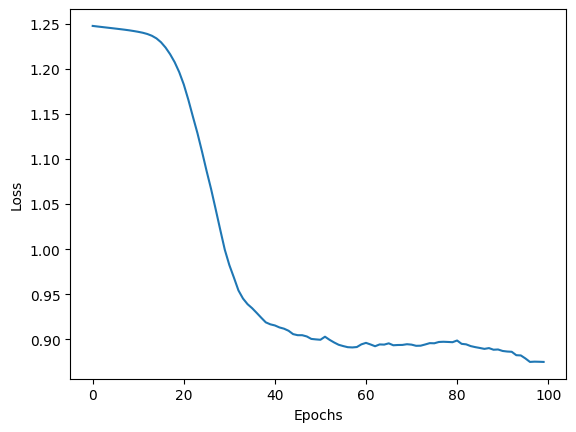

In [14]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

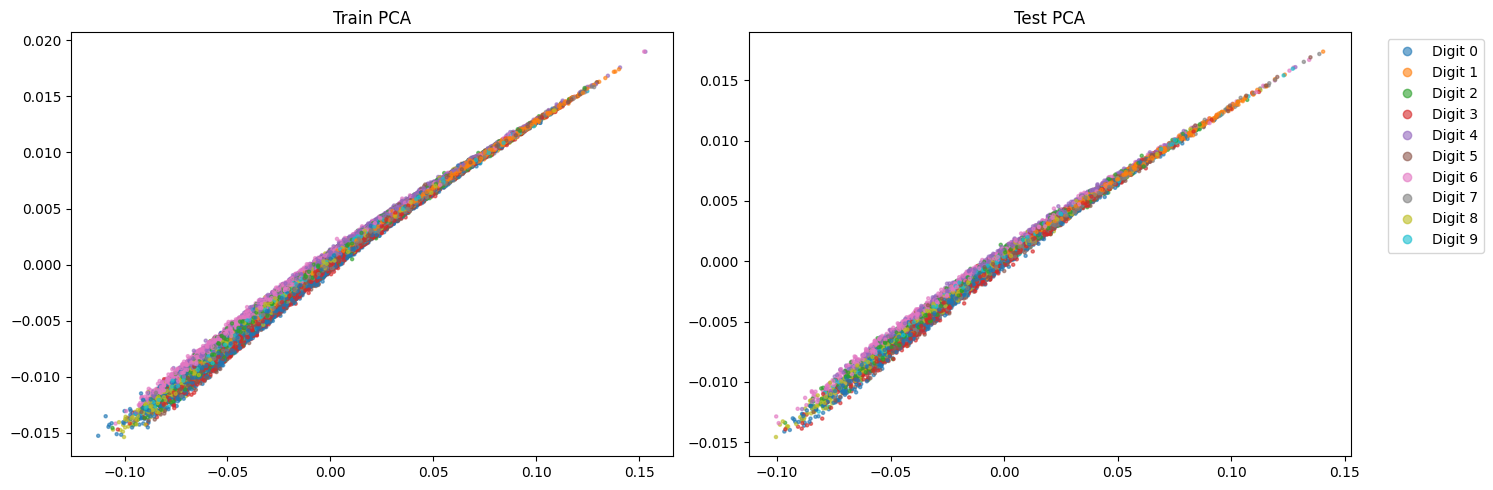

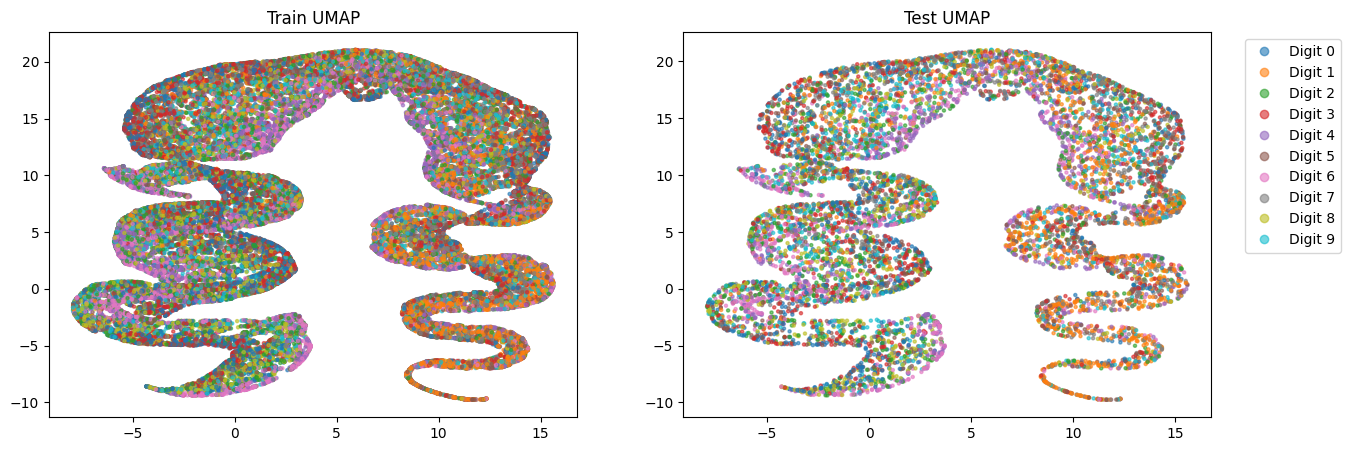

In [15]:
visualize(autoencoder, "mps")

# AutoEncoder with DMSL

In [16]:
class EncoderDMSL(Encoder):
    def __init__(self):
        super().__init__()
        with torch.no_grad():
            sample = torch.randn(1, 1, 28, 28)
            sample = self.encoder(sample)
            n_flatten = sample.flatten(start_dim=1).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, n_flatten),
            nn.ReLU(),
        )
        self.weights = None

    def forward(self, x, epoch):
        x = self.encoder(x)
        x = x.flatten(start_dim=1)
        x = self.linear(x)

        raw = x.detach().cpu().numpy()
        if epoch == 0:
            shifted, self.weights, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=500, k=50)
        else:
            shifted, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=500, k=50, weights=self.weights)
        shift = torch.tensor(shifted - raw, dtype=torch.float, device=x.device, requires_grad=False)

        x = x + shift
        x = x.reshape(-1, 64, 1, 1)
        return x

In [17]:
class AEwithDMSL(AE):
    def __init__(self):
        super().__init__()
        self.encoder = EncoderDMSL()

    def forward(self, x, epoch):
        x = self.encoder(x, epoch)
        x = self.decoder(x)
        return x

In [18]:
ae_dmsl = AEwithDMSL().float()
history, knn = train(ae_dmsl, "mps", epochs=50)

DMSL shifts:  21%|██        | 103/500 [00:03<00:13, 30.08it/s]


Epoch 00 | Full-Batch Loss: 1.3007


DMSL shifts: 100%|██████████| 500/500 [00:13<00:00, 36.74it/s]


Epoch 10 | Full-Batch Loss: 1.2947


DMSL shifts: 100%|██████████| 500/500 [00:13<00:00, 36.38it/s]


...

DMSL shifts: 100%|██████████| 500/500 [00:13<00:00, 36.35it/s]


Epoch 30 | Full-Batch Loss: 0.9038


DMSL shifts: 100%|██████████| 500/500 [00:13<00:00, 36.37it/s]


Epoch 40 | Full-Batch Loss: 0.8897


DMSL shifts: 100%|██████████| 500/500 [00:13<00:00, 36.29it/s]


In [19]:
score = test(ae_dmsl.encoder, "mps", knn)
print(f"Score: {score}")

DMSL shifts: 100%|██████████| 500/500 [00:01<00:00, 281.22it/s]


Score: 0.423


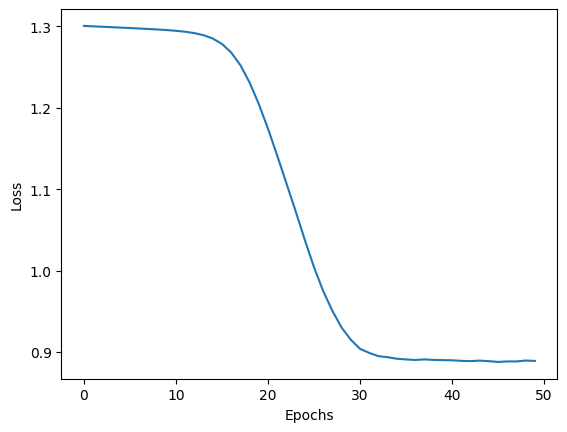

In [20]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

DMSL shifts: 100%|██████████| 500/500 [00:01<00:00, 284.79it/s]


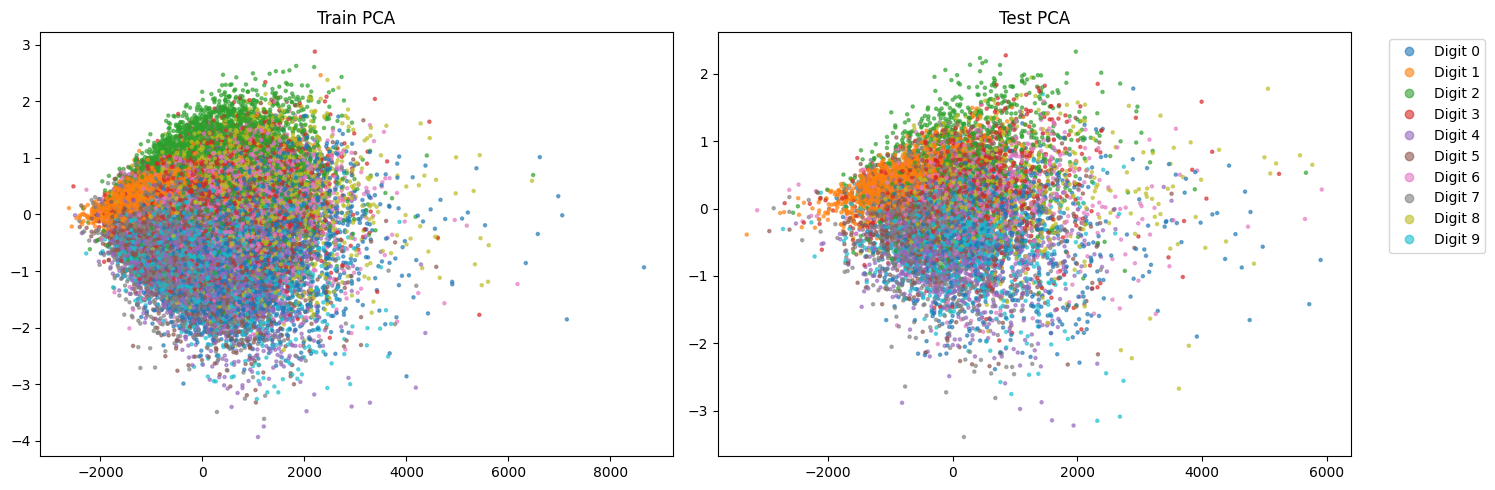

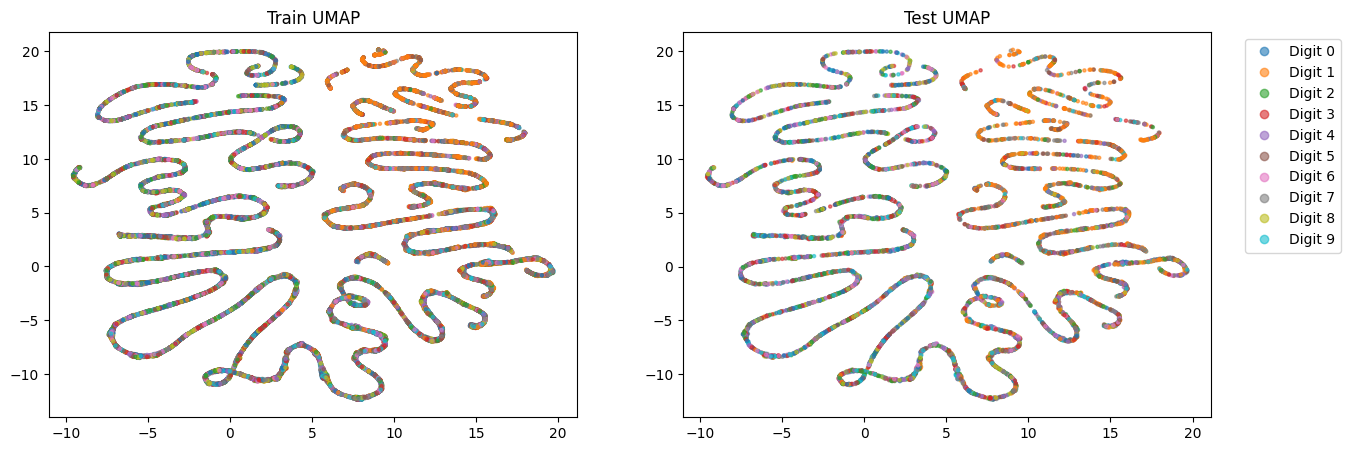

In [21]:
visualize(ae_dmsl.encoder, "mps")

# DMSL as Teacher

In [9]:
def distill_train(model, device, epochs=50):
    history = []
    knn = KNeighborsClassifier()

    model.to(device)
    data = train_dataset.data.to(device)
    data = data.unsqueeze(1)

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        pred = model(data, epoch=epoch)
        raw = pred.flatten(start_dim=1).detach().cpu().numpy()

        if epoch == 0:
            shifted, weights, _, _ = mean_shift_manifold_learning(raw, max_iters_shift=500, k=50)
        else:
            shifted, _, _ =mean_shift_manifold_learning(raw, max_iters_shift=500, k=50, weights=weights)

        shifted = torch.tensor(shifted, dtype=torch.float, device=device).view(-1, 64, 1, 1)
        loss = criterion(pred, shifted)

        loss.backward()
        optimizer.step()

        history.append(loss.item())
        if epoch % 1 == 0:
            print(f"Epoch {epoch:02d} | Full-Batch Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        emb = model(data)
        emb = emb.flatten(start_dim=1).cpu().numpy()

    knn.fit(emb, train_dataset.targets)
    return history, knn

In [12]:
encoder = Encoder().float()
history, knn = distill_train(encoder, "mps", epochs=500)

DMSL shifts:  42%|████▏     | 210/500 [00:06<00:09, 31.37it/s]


Epoch 00 | Full-Batch Loss: 0.0000


DMSL shifts:  33%|███▎      | 167/500 [00:04<00:09, 35.89it/s]


Epoch 01 | Full-Batch Loss: 0.0000


DMSL shifts:  27%|██▋       | 136/500 [00:03<00:10, 35.61it/s]


...

Epoch 497 | Full-Batch Loss: 0.0000


DMSL shifts:  19%|█▉        | 95/500 [00:02<00:11, 35.99it/s]


Epoch 498 | Full-Batch Loss: 0.0000


DMSL shifts:  19%|█▉        | 94/500 [00:02<00:11, 35.86it/s]


Epoch 499 | Full-Batch Loss: 0.0000


In [17]:
score = test(encoder, "mps", knn)
print(f"Score: {score}")

Score: 0.2524


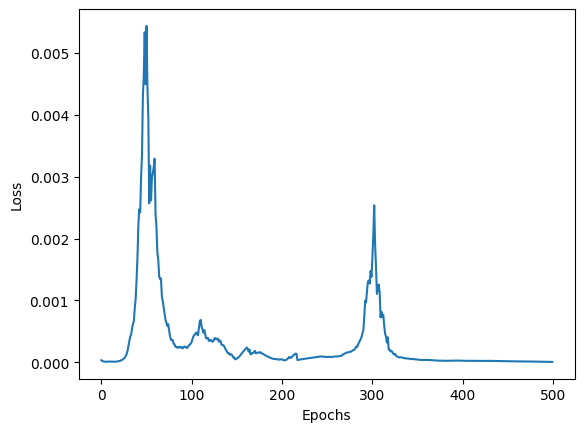

In [13]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

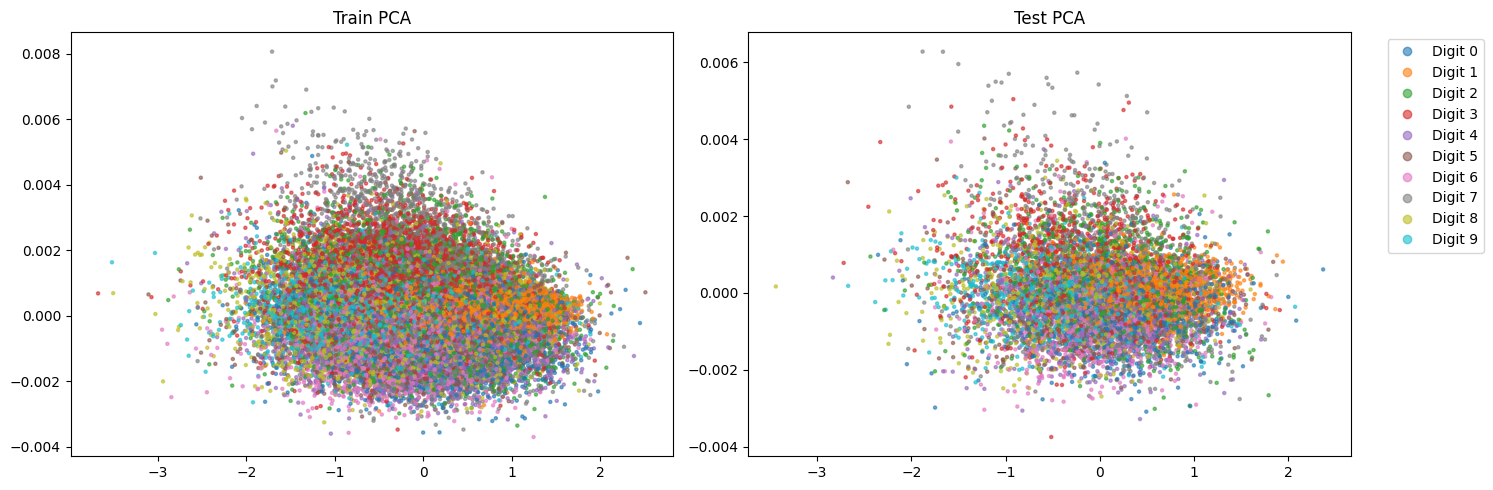

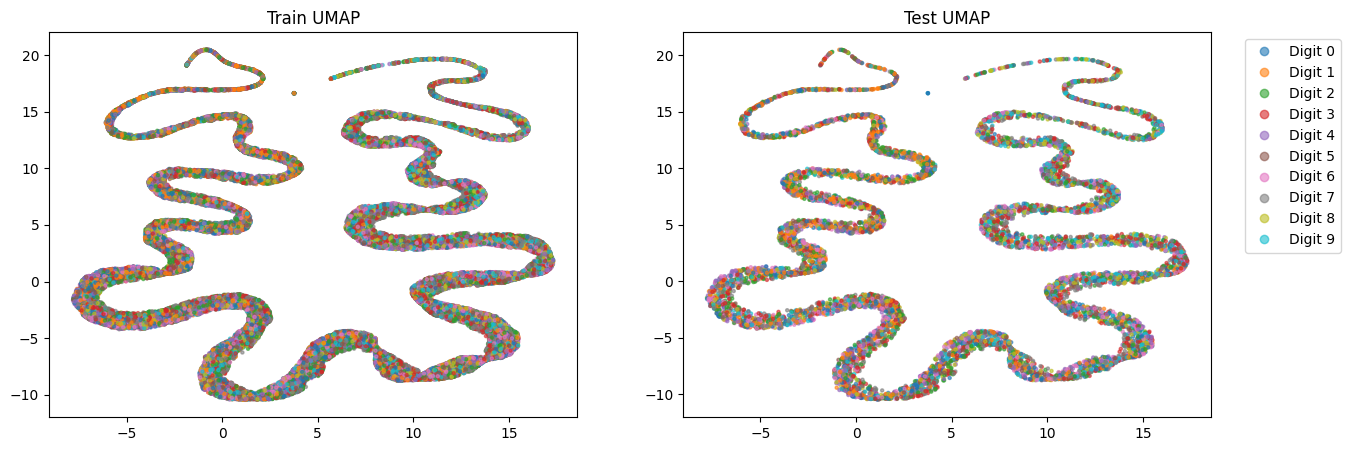

In [14]:
visualize(encoder, "mps")